In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve
import statsmodels.api as sm
from scipy import stats

In [41]:
data = pd.read_csv(r'C:\Users\utkso\OneDrive\Desktop\bike+sharing+dataset\hour.csv')

In [42]:
# Drop non-predictive columns (ID and Date)
data = data.drop(['instant', 'dteday'], axis=1)

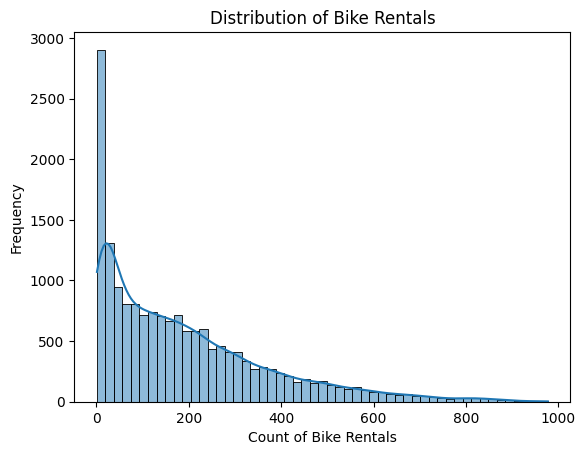

In [43]:
# Visualize the distribution of the target variable 'cnt'
sns.histplot(data['cnt'], kde=True)
plt.title('Distribution of Bike Rentals')
plt.xlabel('Count of Bike Rentals')
plt.ylabel('Frequency')
plt.show()

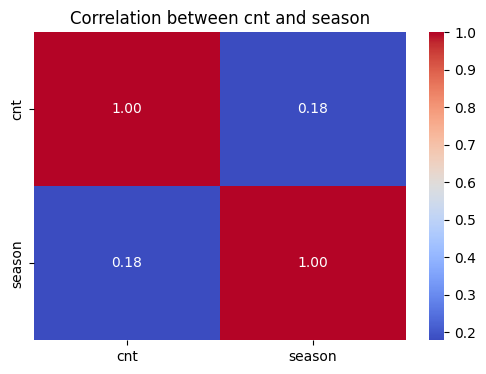

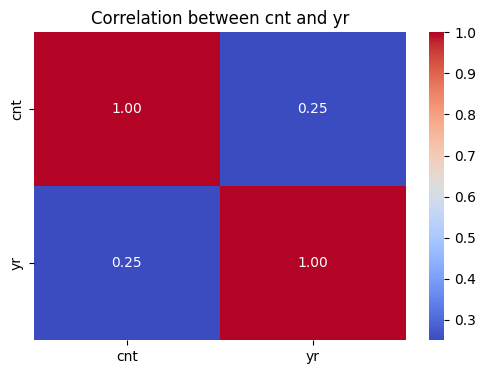

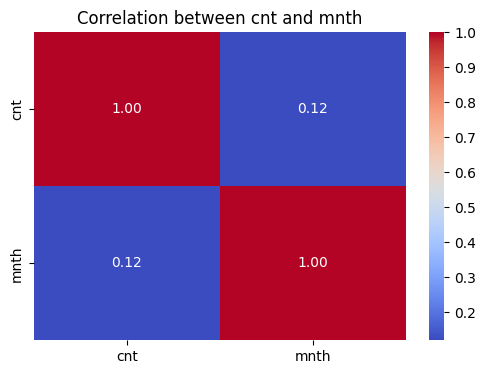

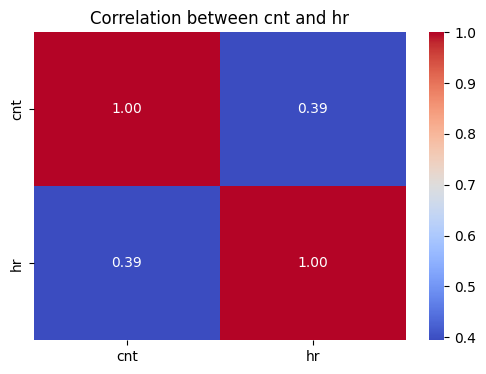

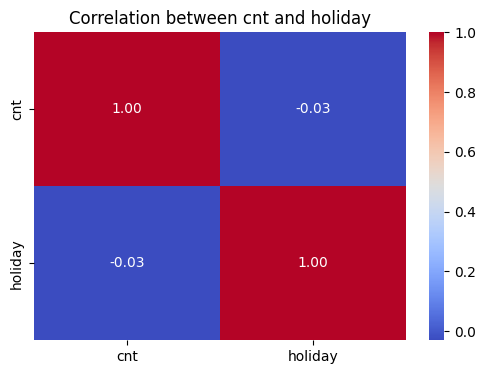

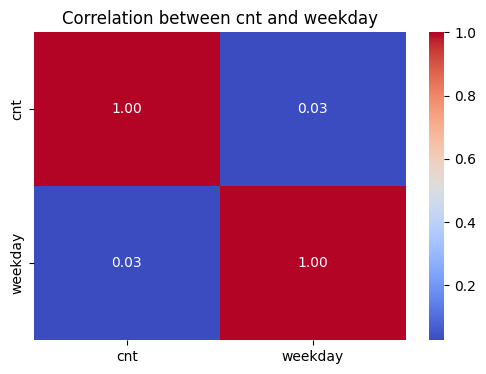

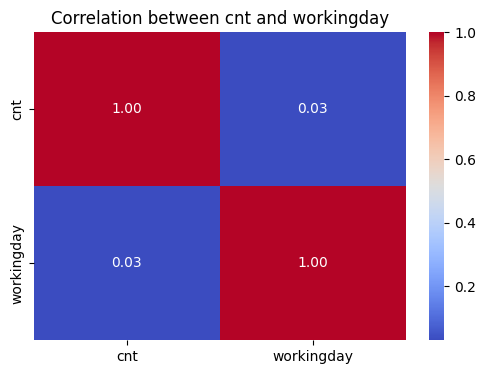

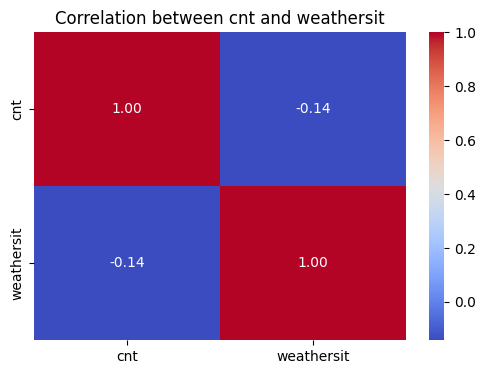

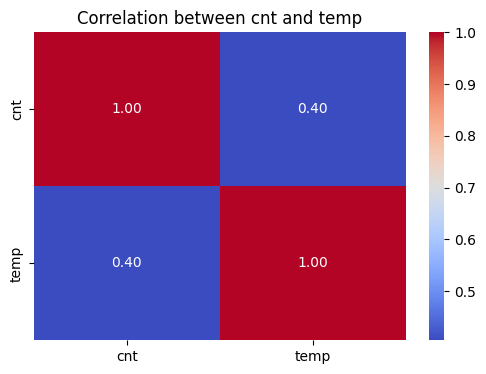

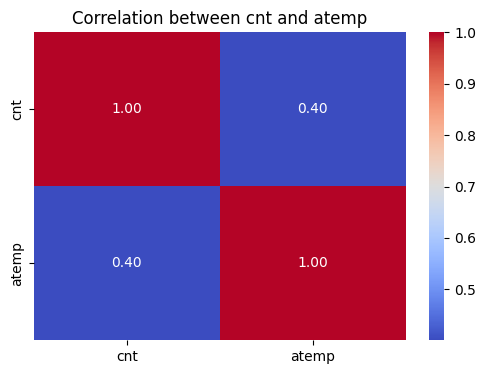

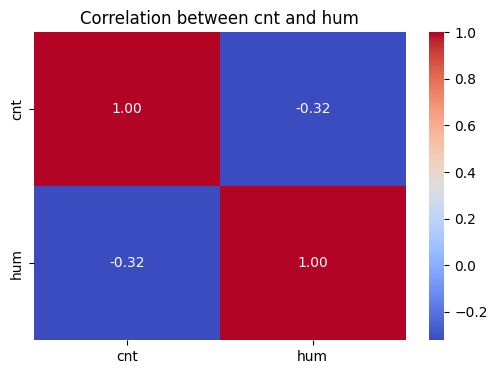

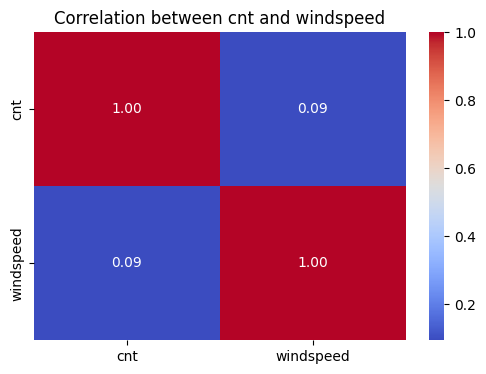

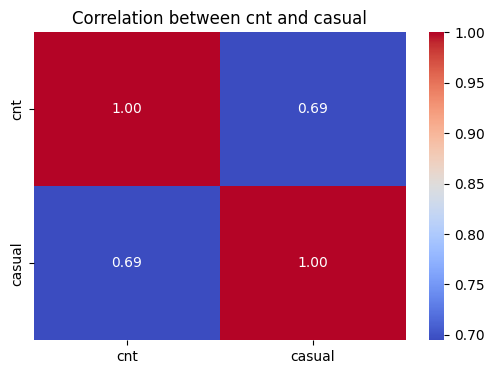

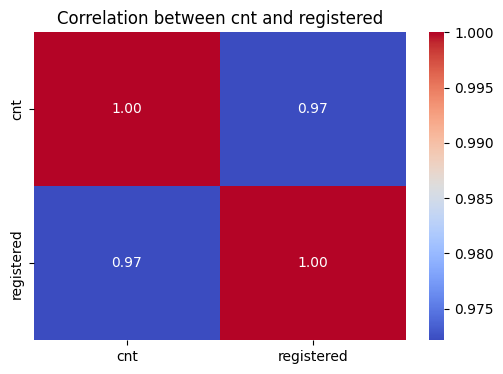

In [44]:
for column in data.columns:
    if column != 'cnt':  # Exclude 'cnt' from predictor variables
        plt.figure(figsize=(6, 4))
        sns.heatmap(data[['cnt', column]].corr(), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title(f'Correlation between cnt and {column}')
        plt.show()

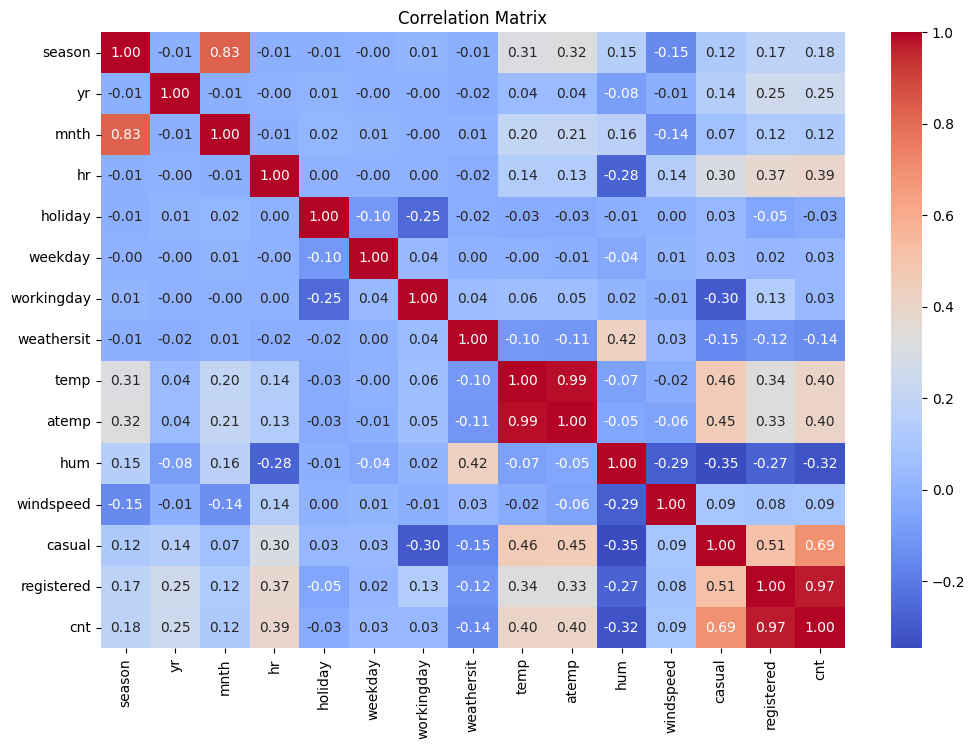

In [45]:
# Correlation Analysis
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [46]:
# ANOVA for categorical variables
categorical_vars = ['season', 'holiday', 'weathersit', 'mnth', 'workingday']
for var in categorical_vars:
    print(f"ANOVA for {var}:")
    f_statistic, p_value = stats.f_oneway(*[data[data[var] == value]['cnt'] for value in data[var].unique()])
    print(f"F-statistic: {f_statistic}, p-value: {p_value}")


ANOVA for season:
F-statistic: 409.1810372630525, p-value: 7.40107139971279e-257
ANOVA for holiday:
F-statistic: 16.636980484977737, p-value: 4.546168948723332e-05
ANOVA for weathersit:
F-statistic: 127.17386949967266, p-value: 1.7347820521803117e-81
ANOVA for mnth:
F-statistic: 128.1021897089323, p-value: 5.50568493648436e-284
ANOVA for workingday:
F-statistic: 15.95182279420313, p-value: 6.524264547051995e-05


C:\Users\utkso\AppData\Local\Temp\ipykernel_9876\3583299488.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=var, y='cnt', data=data, ci='sd')
C:\Users\utkso\AppData\Local\Temp\ipykernel_9876\3583299488.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=var, y='cnt', data=data, ci='sd')
C:\Users\utkso\AppData\Local\Temp\ipykernel_9876\3583299488.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=var, y='cnt', data=data, ci='sd')
C:\Users\utkso\AppData\Local\Temp\ipykernel_9876\3583299488.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=var, y='cnt', data=data, ci='sd')
C:\Users\utkso\AppData\Local\Temp\ipykernel_9876\3583299488.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.



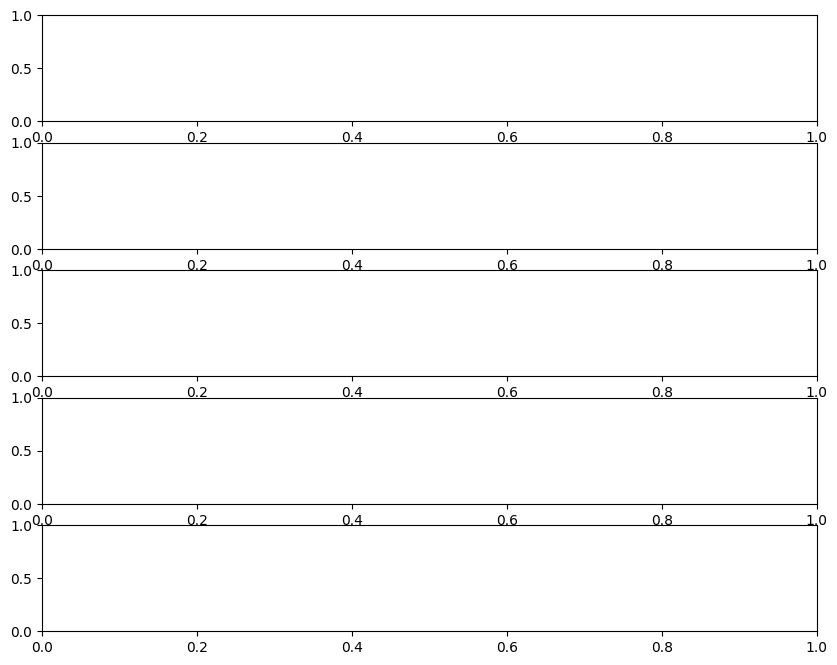

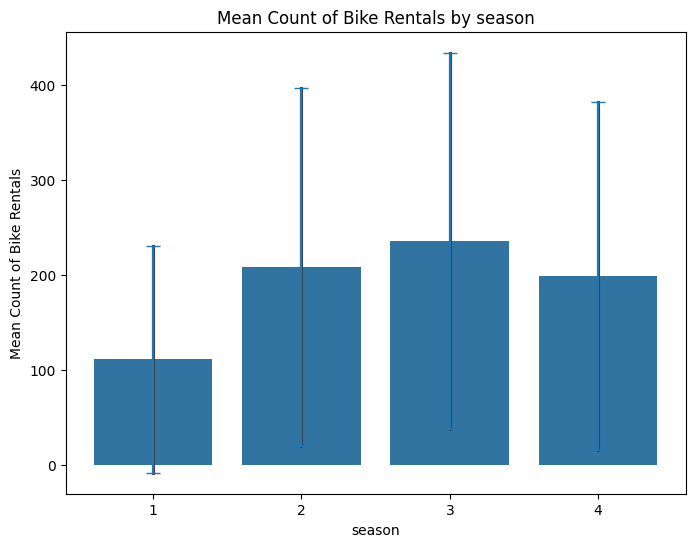

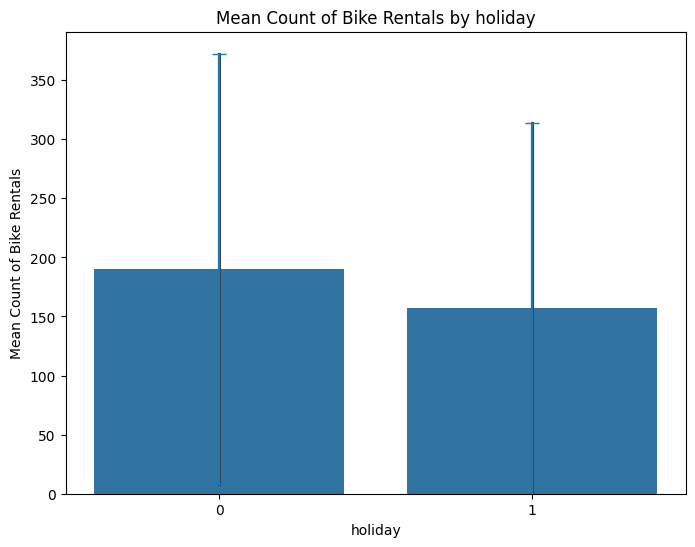

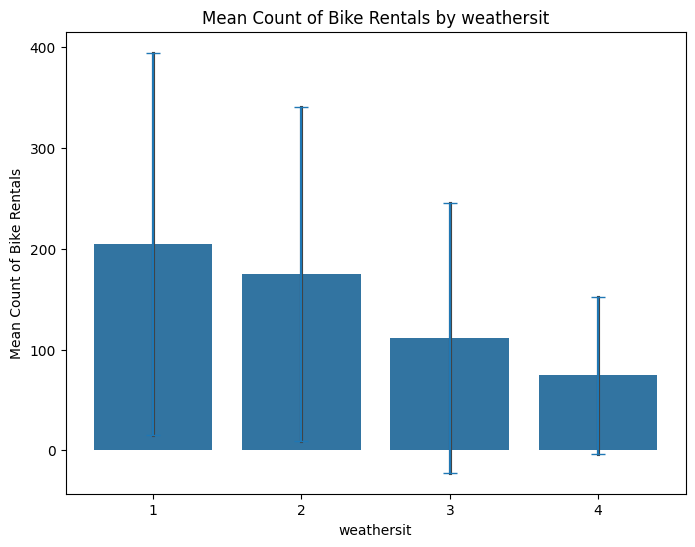

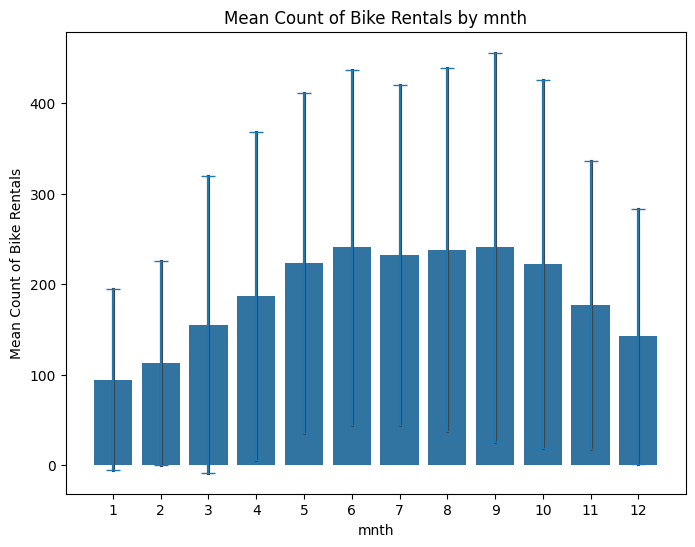

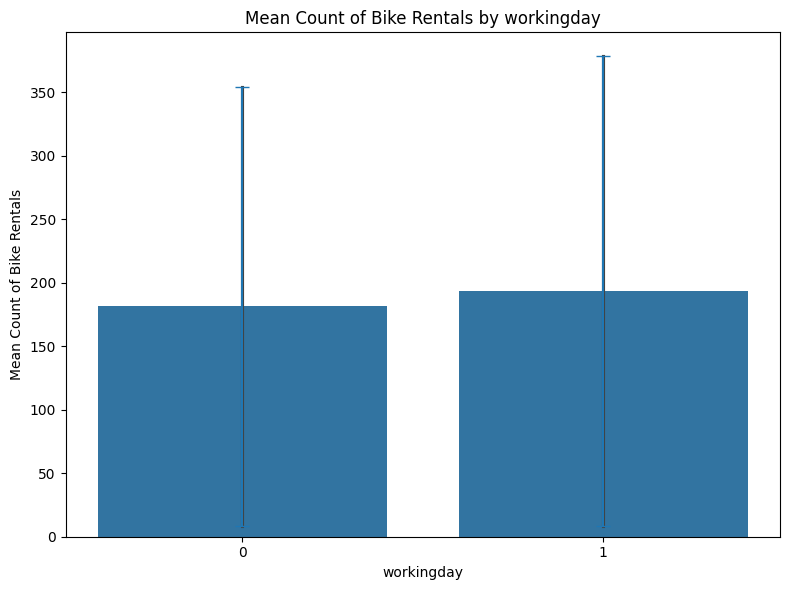

In [47]:
# Create subplots for each categorical variable
fig, axes = plt.subplots(len(categorical_vars), 1, figsize=(10, 8), sharey=True)

# Loop through each categorical variable
for i, var in enumerate(categorical_vars):
    # Create a new figure for each variable
    plt.figure(figsize=(8, 6))
    
    # Calculate mean count of bike rentals for each category
    mean_count = data.groupby(var)['cnt'].mean().reset_index()
    
    # Calculate standard deviation of bike rentals for each category
    std_count = data.groupby(var)['cnt'].std().reset_index()
    
    # Plot bar plot with error bars
    sns.barplot(x=var, y='cnt', data=data, ci='sd')
    
    # Add labels and title
    plt.title(f'Mean Count of Bike Rentals by {var}')
    plt.xlabel(var)
    plt.ylabel('Mean Count of Bike Rentals')
    
    # Add error bars
    plt.errorbar(x=mean_count.index, y=mean_count['cnt'], yerr=std_count['cnt'], fmt='none', capsize=5)

plt.tight_layout()
plt.show()


T-statistic: -0.22306957521789678, p-value: 0.8234839791816918


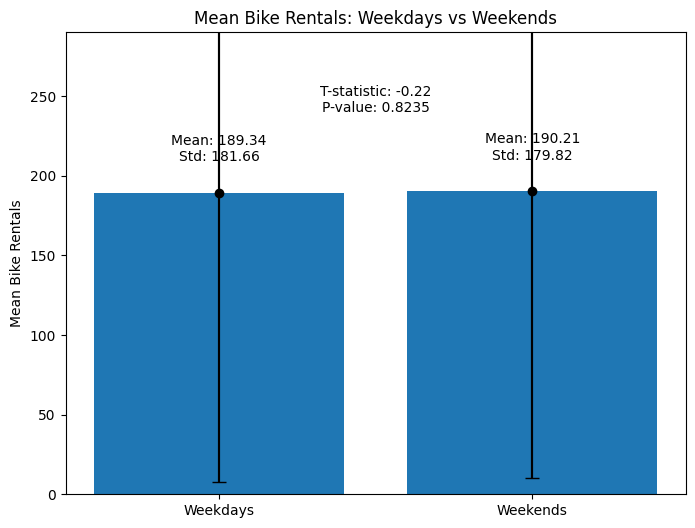

In [48]:
# Splitting data into weekdays and weekends
weekday_cnt = data[data['weekday'] <= 5]['cnt']
weekend_cnt = data[data['weekday'] > 5]['cnt']

# Performing the t-test
t_statistic, p_value = stats.ttest_ind(weekday_cnt, weekend_cnt)
print(f"T-statistic: {t_statistic}, p-value: {p_value}")

# Calculate means and standard deviations for weekdays and weekends
weekday_mean = weekday_cnt.mean()
weekend_mean = weekend_cnt.mean()
weekday_std = weekday_cnt.std()
weekend_std = weekend_cnt.std()

# Create bar plot
plt.figure(figsize=(8, 6))
plt.bar(['Weekdays', 'Weekends'], [weekday_mean, weekend_mean], 
        yerr=[weekday_std, weekend_std], capsize=5)
plt.title('Mean Bike Rentals: Weekdays vs Weekends')
plt.ylabel('Mean Bike Rentals')
plt.errorbar(['Weekdays', 'Weekends'], [weekday_mean, weekend_mean], 
             yerr=[weekday_std, weekend_std], fmt='o', color='black')

# Adding annotations
plt.text(0, weekday_mean + 20, f'Mean: {weekday_mean:.2f}\nStd: {weekday_std:.2f}', ha='center')
plt.text(1, weekend_mean + 20, f'Mean: {weekend_mean:.2f}\nStd: {weekend_std:.2f}', ha='center')
plt.text(0.5, max(weekday_mean, weekend_mean) + 50, f"T-statistic: {t_statistic:.2f}\nP-value: {p_value:.4f}", ha='center')
plt.ylim(0, max(weekday_mean, weekend_mean) + 100)

plt.show()


C:\Users\utkso\AppData\Local\Temp\ipykernel_9876\505018097.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='season', y='cnt', data=data, palette='Set3')


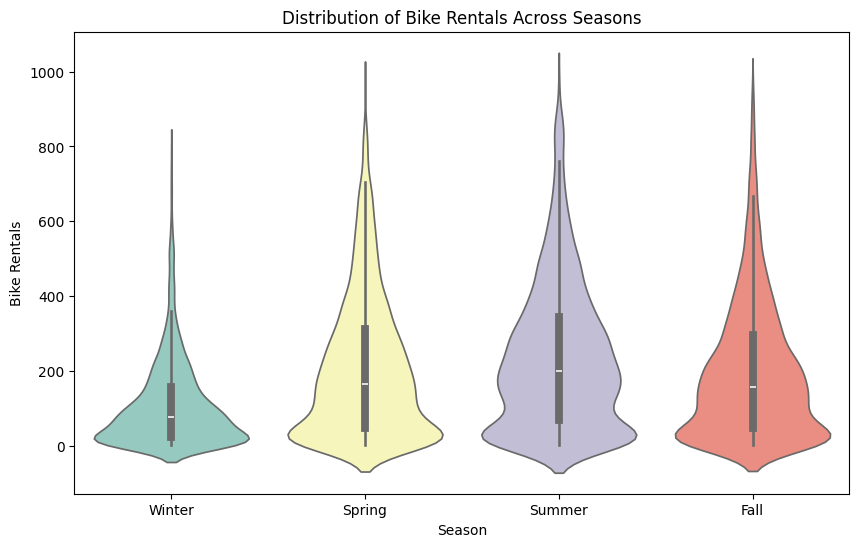

T-test between Season 1 and Season 2: T-statistic=-28.56, p-value=0.0000
T-test between Season 1 and Season 3: T-statistic=-35.50, p-value=0.0000
T-test between Season 1 and Season 4: T-statistic=-26.16, p-value=0.0000
T-test between Season 2 and Season 1: T-statistic=28.56, p-value=0.0000
T-test between Season 2 and Season 3: T-statistic=-6.76, p-value=0.0000
T-test between Season 2 and Season 4: T-statistic=2.37, p-value=0.0178
T-test between Season 3 and Season 1: T-statistic=35.50, p-value=0.0000
T-test between Season 3 and Season 2: T-statistic=6.76, p-value=0.0000
T-test between Season 3 and Season 4: T-statistic=9.09, p-value=0.0000
T-test between Season 4 and Season 1: T-statistic=26.16, p-value=0.0000
T-test between Season 4 and Season 2: T-statistic=-2.37, p-value=0.0178
T-test between Season 4 and Season 3: T-statistic=-9.09, p-value=0.0000


In [49]:
# Visualize the distribution of bike rentals across seasons using violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='season', y='cnt', data=data, palette='Set3')
plt.title('Distribution of Bike Rentals Across Seasons')
plt.xlabel('Season')
plt.ylabel('Bike Rentals')
plt.xticks(range(4), ['Winter', 'Spring', 'Summer', 'Fall'])
plt.show()

# Conduct pairwise hypothesis testing between seasons using t-tests
season_combinations = [(s1, s2) for s1 in range(1, 5) for s2 in range(1, 5) if s1 != s2]
for s1, s2 in season_combinations:
    season1_cnt = data[data['season'] == s1]['cnt']
    season2_cnt = data[data['season'] == s2]['cnt']
    t_statistic, p_value = stats.ttest_ind(season1_cnt, season2_cnt)
    print(f"T-test between Season {s1} and Season {s2}: T-statistic={t_statistic:.2f}, p-value={p_value:.4f}")

C:\Users\utkso\AppData\Local\Temp\ipykernel_9876\896544347.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bracket_means = data.groupby('windspeed_bracket')['cnt'].mean()
C:\Users\utkso\AppData\Local\Temp\ipykernel_9876\896544347.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='windspeed_bracket', y='cnt', data=data, palette='Blues', whis=1.5)


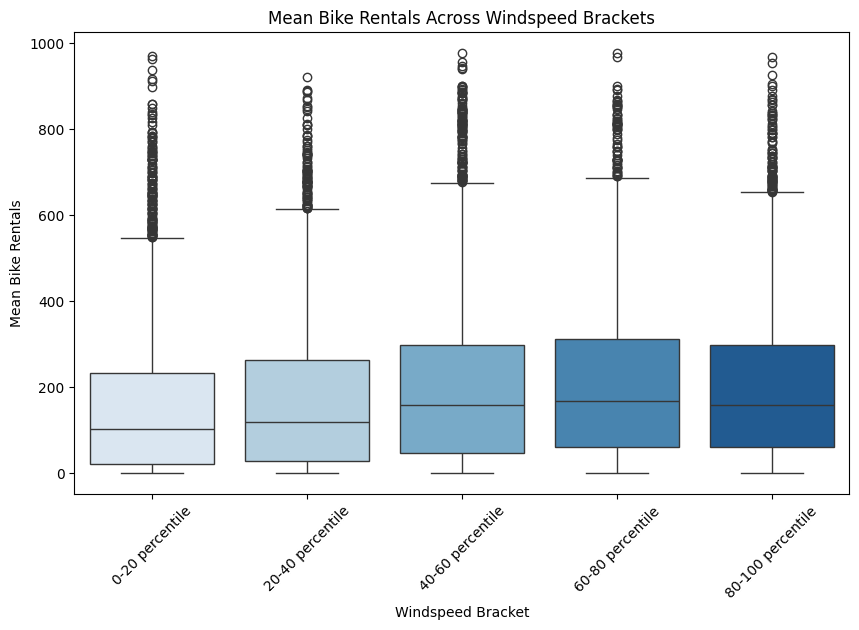

T-test between Windspeed Brackets 0-20 percentile and 20-40 percentile: T-statistic=-3.68, p-value=0.0002
T-test between Windspeed Brackets 0-20 percentile and 40-60 percentile: T-statistic=-11.77, p-value=0.0000
T-test between Windspeed Brackets 0-20 percentile and 60-80 percentile: T-statistic=-12.35, p-value=0.0000
T-test between Windspeed Brackets 0-20 percentile and 80-100 percentile: T-statistic=-11.88, p-value=0.0000
T-test between Windspeed Brackets 20-40 percentile and 0-20 percentile: T-statistic=3.68, p-value=0.0002
T-test between Windspeed Brackets 20-40 percentile and 40-60 percentile: T-statistic=-7.70, p-value=0.0000
T-test between Windspeed Brackets 20-40 percentile and 60-80 percentile: T-statistic=-8.89, p-value=0.0000
T-test between Windspeed Brackets 20-40 percentile and 80-100 percentile: T-statistic=-8.09, p-value=0.0000
T-test between Windspeed Brackets 40-60 percentile and 0-20 percentile: T-statistic=11.77, p-value=0.0000
T-test between Windspeed Brackets 40-60

In [50]:
# Define percentiles to create brackets for windspeed
percentiles = [0, 20, 40, 60, 80, 100]

# Create brackets for windspeed using percentiles
windspeed_brackets = np.percentile(data['windspeed'], percentiles)

# Assign labels to windspeed brackets
windspeed_labels = [f"{percentiles[i]}-{percentiles[i+1]} percentile" for i in range(len(percentiles)-1)]

# Map windspeed values to corresponding brackets
data['windspeed_bracket'] = pd.cut(data['windspeed'], bins=windspeed_brackets, labels=windspeed_labels, include_lowest=True)

# Calculate mean bike rentals for each windspeed bracket
bracket_means = data.groupby('windspeed_bracket')['cnt'].mean()

# Create a box plot to visualize mean bike rentals across windspeed brackets
# Create a box plot with adjusted parameters
plt.figure(figsize=(10, 6))
sns.boxplot(x='windspeed_bracket', y='cnt', data=data, palette='Blues', whis=1.5)
plt.title('Mean Bike Rentals Across Windspeed Brackets')
plt.xlabel('Windspeed Bracket')
plt.ylabel('Mean Bike Rentals')
plt.xticks(rotation=45)
plt.show()

# Conduct pairwise hypothesis testing between windspeed brackets using t-tests
bracket_combinations = [(b1, b2) for b1 in windspeed_labels for b2 in windspeed_labels if b1 != b2]
for b1, b2 in bracket_combinations:
    bracket1_cnt = data[data['windspeed_bracket'] == b1]['cnt']
    bracket2_cnt = data[data['windspeed_bracket'] == b2]['cnt']
    t_statistic, p_value = stats.ttest_ind(bracket1_cnt, bracket2_cnt)
    print(f"T-test between Windspeed Brackets {b1} and {b2}: T-statistic={t_statistic:.2f}, p-value={p_value:.4f}")


In [51]:
data.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,windspeed_bracket
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,0-20 percentile
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,0-20 percentile
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,0-20 percentile
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,0-20 percentile
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,0-20 percentile


In [52]:
data = data.drop(['windspeed_bracket'], axis=1)

In [53]:
#Build Model
model=smf.ols('cnt~season+yr+mnth+hr+holiday+weekday+workingday+weathersit+temp+atemp+hum+windspeed+casual+registered',data=data).fit()

In [55]:
model.params


Intercept     1.454732e-12
season       -4.651418e-13
yr            2.004646e-14
mnth         -4.825307e-14
hr           -1.448277e-14
holiday      -9.259954e-15
weekday      -2.267370e-14
workingday   -5.544176e-14
weathersit    4.791653e-14
temp         -1.349528e-13
atemp        -1.504699e-13
hum           1.814521e-15
windspeed     4.968248e-14
casual        1.000000e+00
registered    1.000000e+00
dtype: float64

In [56]:
model.tvalues,np.round(model.pvalues,5)

(Intercept     2.850060e+01
 season       -3.549184e+01
 yr            1.240215e+00
 mnth         -1.185247e+01
 hr           -1.153665e+01
 holiday      -1.924404e-01
 weekday      -5.835982e+00
 workingday   -2.819044e+00
 weathersit    3.500311e+00
 temp         -5.082202e-01
 atemp        -5.042981e-01
 hum           3.510826e-02
 windspeed     7.183875e-01
 casual        4.322100e+15
 registered    1.466219e+16
 dtype: float64,
 Intercept     0.00000
 season        0.00000
 yr            0.21491
 mnth          0.00000
 hr            0.00000
 holiday       0.84740
 weekday       0.00000
 workingday    0.00482
 weathersit    0.00047
 temp          0.61131
 atemp         0.61406
 hum           0.97199
 windspeed     0.47253
 casual        0.00000
 registered    0.00000
 dtype: float64)

In [57]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.939e+31
Date:                Fri, 07 Jun 2024   Prob (F-statistic):               0.00
Time:                        19:02:26   Log-Likelihood:             4.5523e+05
No. Observations:               17379   AIC:                        -9.104e+05
Df Residuals:                   17364   BIC:                        -9.103e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.455e-12    5.1e-14     28.501      0.000    1.35e-12    1.55e-12
season     -4.651e-13   1.31e-14    -35.492      0.000   -4.91e-13   -4.39e-13
yr          2.005e-14   1.62e-14      1.240      0.215   -1.16e-14    5.17e-14
mnth       -4.825e-14   4.07e-15    -11.852      0.000   -5.62e-14   -4.03e-14
hr         -1.448e-14   1.26e-15    -11.537      0.000   -1.69e-14    -1.2e-14
holiday     -9.26e-15   4.81e-14     -0.192      0.847   -1.04e-13    8.51e-14
weekday    -2.267e-14   3.89e-15     -5.836      0.000   -3.03e-14   -1.51e-14
workingday -5.544e-14   1.97e-14     -2.819      0.005    -9.4e-14   -1.69e-14
weathersit  4.792e-14   1.37e-14      3.500      0.000    2.11e-14    7.47e-14
temp        -1.35e-13   2.66e-13     -0.508      0.611   -6.55e-13    3.86e-13
atemp      -1.505e-13   2.98e-13     -0.504      0.614   -7.35e-13    4.34e-13
hum         1.815e-15   5.17e-14      0.035      0.972   -9.95e-14    1.03e-13
windspeed   4.968e-14   6.92e-14      0.718      0.473   -8.59e-14    1.85e-13
casual         1.0000   2.31e-16   4.32e+15      0.000       1.000       1.000
registered     1.0000   6.82e-17   1.47e+16      0.000       1.000       1.000
==============================================================================
Omnibus:                     1477.324   Durbin-Watson:                   0.048
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              475.798
Skew:                           0.070   Prob(JB):                    4.81e-104
Kurtosis:                       2.202   Cond. No.                     1.14e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.14e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [58]:
rsq_cnt=smf.ols('cnt~season+yr+mnth+hr+holiday+weekday+workingday+weathersit+temp+atemp+hum+windspeed+casual+registered',data=data).fit().rsquared
vif_cnt=1/(1-rsq_cnt)

rsq_year=smf.ols('yr~cnt+season+mnth+hr+holiday+weekday+workingday+weathersit+temp+atemp+hum+windspeed+casual+registered',data=data).fit().rsquared
vif_year=1/(1-rsq_year)

rsq_hour=smf.ols('hr~cnt+season+yr+mnth+holiday+weekday+workingday+weathersit+temp+atemp+hum+windspeed+casual+registered',data=data).fit().rsquared
vif_hour=1/(1-rsq_hour)

rsq_seas=smf.ols('season~cnt+yr+mnth+hr+holiday+weekday+workingday+weathersit+temp+atemp+hum+windspeed+casual+registered',data=data).fit().rsquared
vif_seas=1/(1-rsq_seas)

rsq_holid=smf.ols('holiday~cnt+season+yr+mnth+hr+weekday+workingday+weathersit+temp+atemp+hum+windspeed+casual+registered',data=data).fit().rsquared
vif_holid=1/(1-rsq_holid)

rsq_workd=smf.ols('workingday~cnt+season+yr+mnth+hr+holiday+weekday+weathersit+temp+atemp+hum+windspeed+casual+registered',data=data).fit().rsquared
vif_workd=1/(1-rsq_workd)

rsq_weath=smf.ols('weathersit~cnt+season+yr+mnth+hr+holiday+weekday+workingday+temp+atemp+hum+windspeed+casual+registered',data=data).fit().rsquared
vif_weath=1/(1-rsq_weath)

rsq_temp=smf.ols('temp~cnt+season+yr+mnth+hr+holiday+weekday+workingday+weathersit+atemp+hum+windspeed+casual+registered',data=data).fit().rsquared
vif_temp=1/(1-rsq_temp)

rsq_atemp=smf.ols('atemp~cnt+season+yr+mnth+hr+holiday+weekday+workingday+weathersit+temp+hum+windspeed+casual+registered',data=data).fit().rsquared
vif_atemp=1/(1-rsq_atemp)

rsq_humid=smf.ols('hum~cnt+season+yr+mnth+hr+holiday+weekday+workingday+weathersit+temp+atemp+windspeed+casual+registered',data=data).fit().rsquared
vif_humid=1/(1-rsq_humid)

rsq_winds=smf.ols('windspeed~cnt+season+yr+mnth+hr+holiday+weekday+workingday+weathersit+temp+atemp+hum+casual+registered',data=data).fit().rsquared
vif_winds=1/(1-rsq_winds)

rsq_casual=smf.ols('casual~cnt+season+yr+mnth+hr+holiday+weekday+workingday+weathersit+temp+atemp+hum+windspeed+registered',data=data).fit().rsquared
vif_casual=1/(1-rsq_casual)

rsq_registered=smf.ols('registered~cnt+season+yr+mnth+hr+holiday+weekday+workingday+weathersit+temp+atemp+hum+windspeed+casual',data=data).fit().rsquared
vif_registered=1/(1-rsq_registered)

df={'Variables':['cnt','yr','hr','season','holiday','workingday','weathersit','temp','atemp','humidity','windspeed','casual','registered'],
   'Vif':[vif_cnt,vif_year,vif_hour,rsq_seas,rsq_holid,rsq_workd,rsq_weath,rsq_temp,rsq_atemp,rsq_humid,rsq_winds,rsq_casual,rsq_registered]}
          
Vif_df=pd.DataFrame(df)
Vif_df

C:\Users\utkso\AppData\Local\Temp\ipykernel_9876\49936613.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  vif_cnt=1/(1-rsq_cnt)
C:\Users\utkso\AppData\Local\Temp\ipykernel_9876\49936613.py:35: RuntimeWarning: divide by zero encountered in scalar divide
  vif_casual=1/(1-rsq_casual)
C:\Users\utkso\AppData\Local\Temp\ipykernel_9876\49936613.py:38: RuntimeWarning: divide by zero encountered in scalar divide
  vif_registered=1/(1-rsq_registered)


,Variables,Vif
0,cnt,inf
1,yr,1.094830
2,hr,1.262889
3,season,0.716506
4,holiday,0.077913
5,workingday,0.287953
6,weathersit,0.221166
7,temp,0.977180
8,atemp,0.977308
9,humidity,0.399954


In [37]:
# Split the data into features (X) and target variable (y)
X = data.drop(['cnt'], axis=1)  # Features
y = data['cnt']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the predictor variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and fit the Ridge regression model
ridge_model = Ridge(alpha=1.0)  # Adjust alpha for regularization strength
ridge_model.fit(X_train_scaled, y_train)

# Predict on the testing set
y_pred = ridge_model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Print coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': ridge_model.coef_})
print(coefficients)

# Print R-squared value
r_squared = ridge_model.score(X_test_scaled, y_test)
print(f"R-squared: {r_squared}")


# Split the data into features (X) and target variable (y)
X = data.drop(['cnt'], axis=1)  # Features
y = data['cnt']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the predictor variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Add constant term for intercept
X_train_scaled = sm.add_constant(X_train_scaled)

# Fit the linear regression model using OLS (Ordinary Least Squares)
model = sm.OLS(y_train, X_train_scaled)

# Fit the model and get the results summary
results = model.fit()

# Print the summary
print(results.summary())



Mean Squared Error: 0.00017407437842347103
       Feature  Coefficient
0       season     0.002299
1           yr     0.003906
2         mnth     0.000045
3           hr     0.004782
4      holiday    -0.000168
5      weekday     0.000187
6   workingday     0.002315
7   weathersit    -0.000382
8         temp     0.000784
9        atemp     0.002563
10         hum    -0.002554
11   windspeed     0.000438
12      casual    49.635229
13  registered   152.012851
R-squared: 0.9999999945026964
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.069e+32
Date:                Fri, 07 Jun 2024   Prob (F-statistic):               0.00
Time:                        18:57:54   Log-Likelihood:             3.7994e+05
No. Observations:               1

In [ ]:
# Make predictions on the testing set
X_test_scaled = sm.add_constant(X_test_scaled)  # Add constant term for intercept
y_pred = model.predict(X_test_scaled)

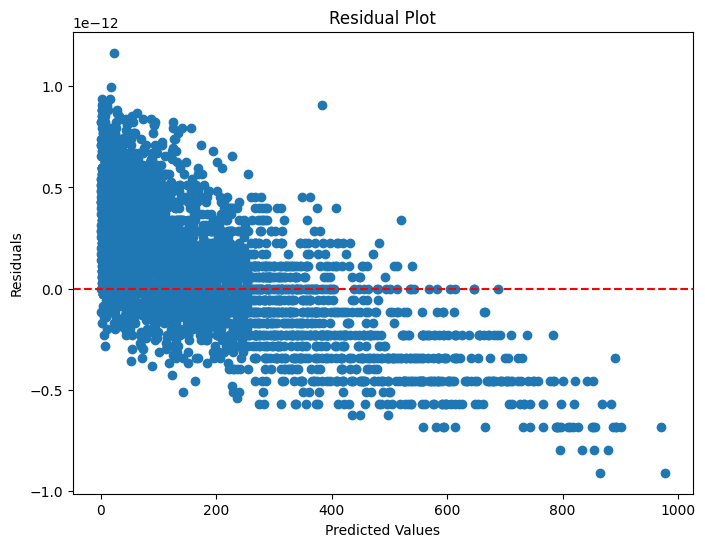

In [ ]:
# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

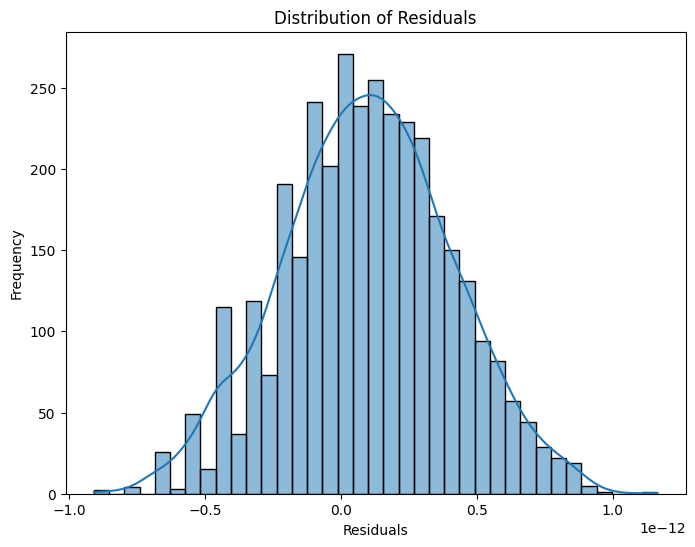

In [ ]:
# Distribution of Residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()


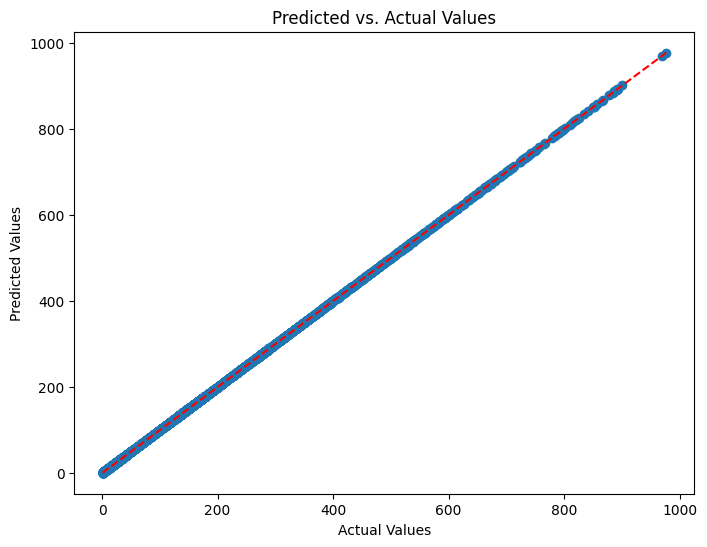

In [ ]:
# Scatter Plot of Predicted vs. Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Predicted vs. Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

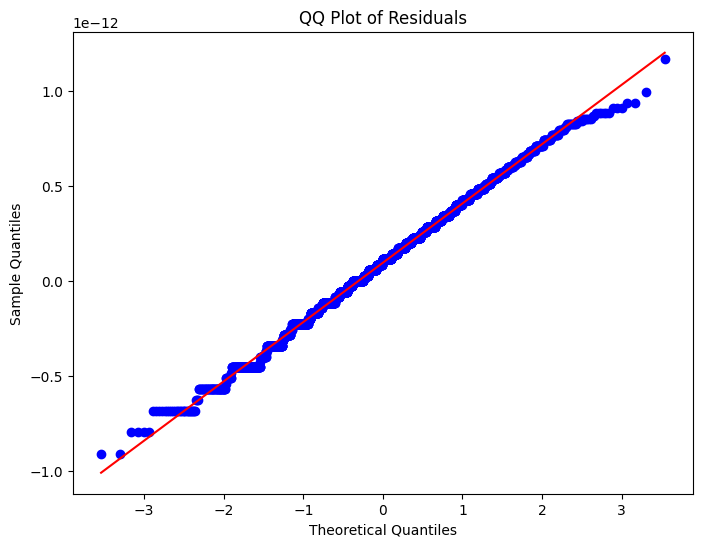

In [ ]:
# QQ Plot
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ Plot of Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

In [ ]:
# Mean Squared Error
mse = np.mean((y_pred - y_test) ** 2)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 1.0640617768134905e-25


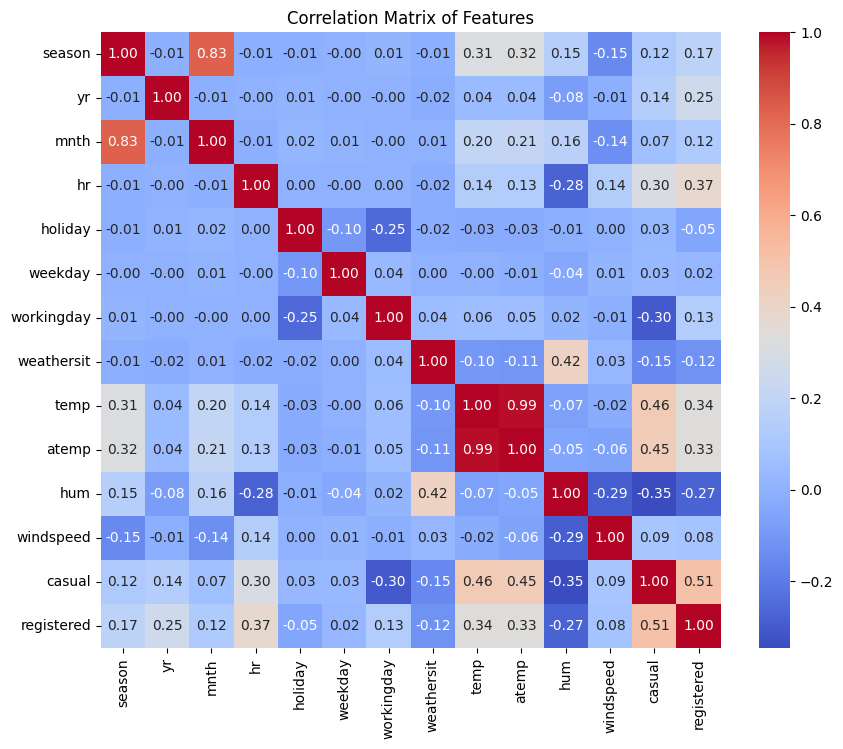

In [60]:
# Calculate correlation matrix
corr_matrix = X.corr()

# Plot heatmap of correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()